# Creative Suffix Attribution Visualizations

Alternative ways to visualize how prefix features influence suffix predictions:

1. **Sankey Diagram** - Flow from features to predictions
2. **Radial Heatmap** - Circular polar visualization
3. **Stream/Area Chart** - Feature importance evolution across suffix
4. **Chord Diagram** - Feature-to-prediction connections
5. **Bump Chart** - Feature rank changes across suffix steps

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

Cases: 6301


In [3]:
# Configuration
CASE_NAME = list(eval_helper.cases.keys())[0]  # Pick first available case
PREFIX_LENGTH = 3
TARGET = CONFIG.concept_name

# Get prefix
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

process = ([t.squeeze(0) for t in prefix[0]], [t.squeeze(0) for t in prefix[1]])
print(f"Case: {CASE_NAME}, Prefix length: {PREFIX_LENGTH}")

Case: Application_1000086665, Prefix length: 3


In [4]:
# Compute attributions for all suffix steps
def compute_all_suffix_attributions(tool, process, prefix_len, target, n_steps=50):
    results = []
    feature_names = None
    step_labels = None

    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names = attr_map.feature_names
                step_labels = attr_map.step_labels

            # Extract predicted activity name
            pred_name = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else f'Step {suffix_step}'
            results.append((suffix_step, attr_map, pred_name))
            print(f"  Suffix {suffix_step}: {pred_name}")

            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Suffix {suffix_step}: Error - {e}")
            break

    return results, feature_names, step_labels

print("Computing attributions...")
results, feature_names, step_labels = compute_all_suffix_attributions(
    tool, process, PREFIX_LENGTH, TARGET, n_steps=CONFIG.ig_steps
)
print(f"\nFeatures: {len(feature_names)}, Prefix steps: {len(step_labels)}, Suffix steps: {len(results)}")

Computing attributions...


  Suffix 0: W_Handle leads


  Suffix 1: W_Handle leads


  Suffix 2: A_Concept


  Suffix 3: W_Complete application

Features: 18, Prefix steps: 4, Suffix steps: 4


In [5]:
# Build attribution cube: (features, prefix_steps, suffix_steps)
# Each suffix step may have a different number of step_labels (encoder
# positions + growing decoder chain). Use the first suffix step's length
# as the prefix dimension and truncate longer vectors.
def build_attribution_cube(results, feature_names):
    n_features = len(feature_names)
    n_prefix = len(results[0][1].step_labels)
    n_suffix = len(results)

    cube = np.zeros((n_features, n_prefix, n_suffix))
    suffix_labels = []

    for s_idx, (_, attr_map, pred_name) in enumerate(results):
        suffix_labels.append(pred_name)
        for f_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                vals = np.asarray(vals).flatten()
                # Truncate to prefix dimension (later suffix steps may
                # include decoder chain positions beyond the prefix)
                length = min(len(vals), n_prefix)
                cube[f_idx, :length, s_idx] = vals[:length]

    return cube, suffix_labels

cube, suffix_labels = build_attribution_cube(results, feature_names)
print(f"Cube shape: {cube.shape}")
print(f"Suffix predictions: {suffix_labels}")

Cube shape: (18, 4, 4)
Suffix predictions: ['W_Handle leads', 'W_Handle leads', 'A_Concept', 'W_Complete application']


## Sankey-style Flow Diagram

Shows how attribution "flows" from features through prefix positions to suffix predictions.

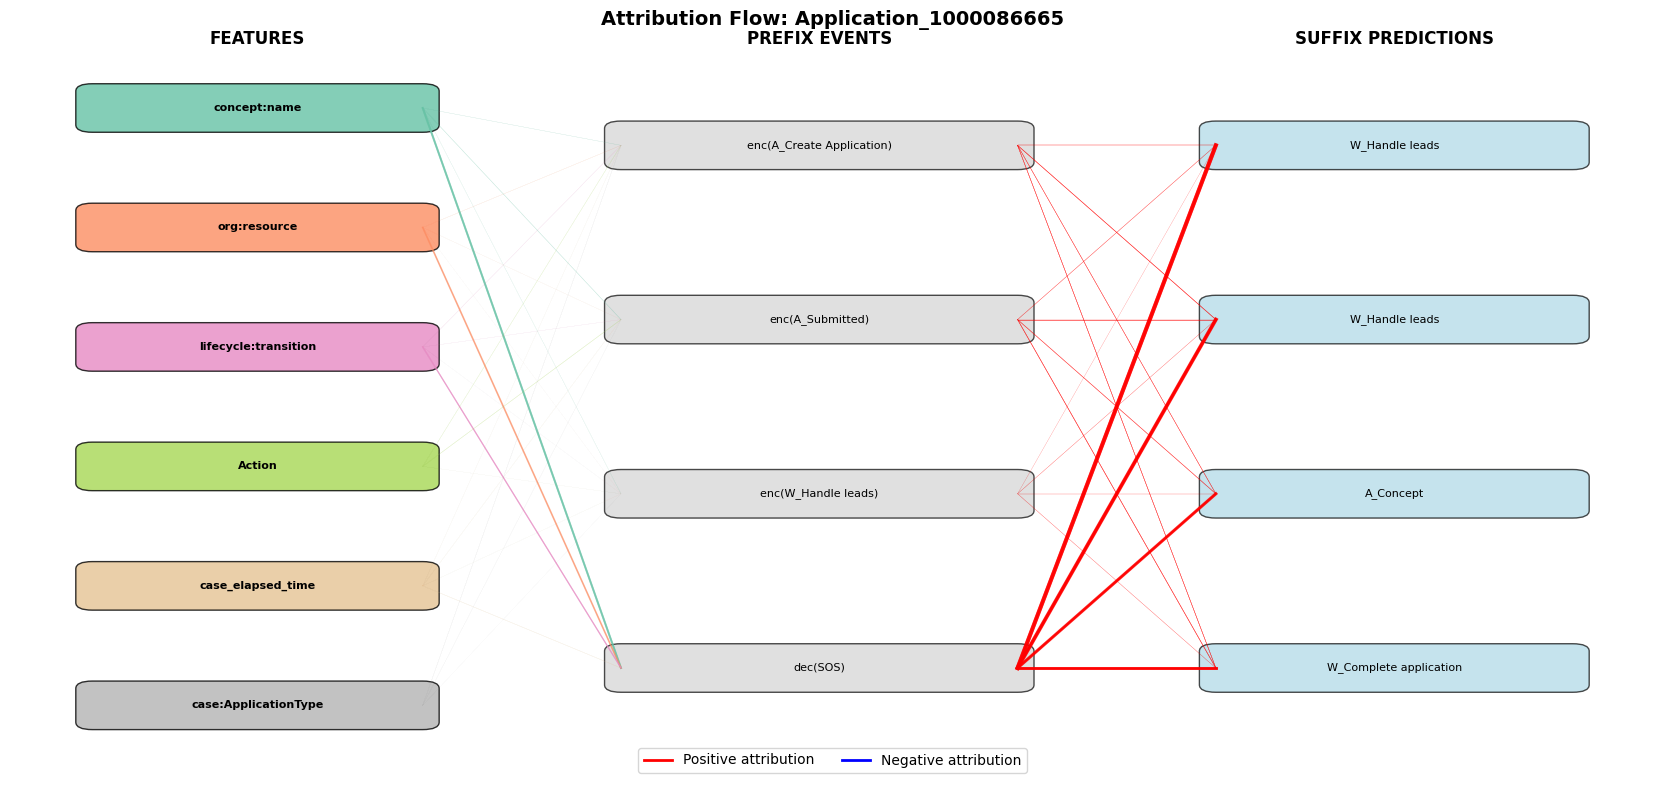

In [6]:
def plot_sankey_style(cube, feature_names, step_labels, suffix_labels, top_k=6):
    """Sankey-style visualization showing feature-to-prediction flow."""
    n_features, n_prefix, n_suffix = cube.shape

    # Get top features by total attribution
    feature_totals = np.abs(cube).sum(axis=(1, 2))
    top_feat_idx = np.argsort(feature_totals)[-top_k:][::-1]

    # Measure longest labels to size columns
    feat_labels = [feature_names[i] for i in top_feat_idx]
    max_feat_len = max(len(s) for s in feat_labels)
    max_prefix_len = max(len(s) for s in step_labels)
    max_suffix_len = max(len(s) for s in suffix_labels)

    # Scale figure width to content
    fig_w = max(16, (max_feat_len + max_prefix_len + max_suffix_len) * 0.25)
    fig, ax = plt.subplots(figsize=(fig_w, max(8, top_k * 1.1)))

    # Column x-centres with enough room for labels
    col_w_feat = max_feat_len * 0.008 + 0.04
    col_w_prefix = max_prefix_len * 0.008 + 0.04
    col_w_suffix = max_suffix_len * 0.008 + 0.04
    gap = 0.12
    total = col_w_feat + gap + col_w_prefix + gap + col_w_suffix
    # Normalize to [0.05, 0.95]
    usable = 0.90
    scale = usable / total
    col_w_feat *= scale
    col_w_prefix *= scale
    col_w_suffix *= scale
    gap *= scale
    x_feat = 0.05 + col_w_feat / 2
    x_prefix = 0.05 + col_w_feat + gap + col_w_prefix / 2
    x_suffix = 0.05 + col_w_feat + gap + col_w_prefix + gap + col_w_suffix / 2

    box_h = 0.045
    colors = plt.cm.Set2(np.linspace(0, 1, top_k))

    # --- Feature boxes (left) ---
    feat_y = np.linspace(0.9, 0.1, top_k)
    for i, (f_idx, y) in enumerate(zip(top_feat_idx, feat_y)):
        box = FancyBboxPatch((x_feat - col_w_feat / 2, y - box_h / 2),
                             col_w_feat, box_h,
                             boxstyle='round,pad=0.01', facecolor=colors[i], alpha=0.8)
        ax.add_patch(box)
        ax.text(x_feat, y, feat_labels[i], ha='center', va='center',
                fontsize=8, fontweight='bold', clip_on=False)

    # --- Prefix boxes (middle) ---
    prefix_y = np.linspace(0.85, 0.15, n_prefix)
    for j, y in enumerate(prefix_y):
        box = FancyBboxPatch((x_prefix - col_w_prefix / 2, y - box_h / 2),
                             col_w_prefix, box_h,
                             boxstyle='round,pad=0.01', facecolor='lightgray', alpha=0.7)
        ax.add_patch(box)
        ax.text(x_prefix, y, step_labels[j], ha='center', va='center',
                fontsize=8, clip_on=False)

    # --- Suffix boxes (right) ---
    suffix_y = np.linspace(0.85, 0.15, n_suffix)
    for s, y in enumerate(suffix_y):
        box = FancyBboxPatch((x_suffix - col_w_suffix / 2, y - box_h / 2),
                             col_w_suffix, box_h,
                             boxstyle='round,pad=0.01', facecolor='lightblue', alpha=0.7)
        ax.add_patch(box)
        ax.text(x_suffix, y, suffix_labels[s], ha='center', va='center',
                fontsize=8, clip_on=False)

    # --- Draw flows ---
    max_attr = np.abs(cube[top_feat_idx]).max()
    for i, f_idx in enumerate(top_feat_idx):
        for j in range(n_prefix):
            for s in range(n_suffix):
                attr = cube[f_idx, j, s]
                if abs(attr) > 0.01:
                    width = abs(attr) / max_attr * 3
                    alpha = min(0.8, abs(attr) / max_attr + 0.2)
                    color = 'red' if attr > 0 else 'blue'
                    ax.plot([x_feat + col_w_feat / 2, x_prefix - col_w_prefix / 2],
                           [feat_y[i], prefix_y[j]],
                           color=colors[i], alpha=alpha * 0.5, linewidth=width * 0.5)
                    ax.plot([x_prefix + col_w_prefix / 2, x_suffix - col_w_suffix / 2],
                           [prefix_y[j], suffix_y[s]],
                           color=color, alpha=alpha, linewidth=width)

    # Column headers
    ax.text(x_feat, 0.98, 'FEATURES', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_prefix, 0.98, 'PREFIX EVENTS', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_suffix, 0.98, 'SUFFIX PREDICTIONS', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.plot([], [], color='red', linewidth=2, label='Positive attribution')
    ax.plot([], [], color='blue', linewidth=2, label='Negative attribution')
    ax.legend(loc='lower center', ncol=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Attribution Flow: {CASE_NAME}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_sankey_style(cube, feature_names, step_labels, suffix_labels)
plt.show()